## 1. What is a Decision Tree, and how does it work for classification problems?

A Decision Tree is a supervised learning algorithm that uses a tree-like structure to make decisions. It works by recursively splitting the dataset based on feature values to create homogeneous subsets.

**How it works for classification:**
- Start with the entire dataset at the root node
- Choose the best feature to split on based on a criterion (like Gini Index or Entropy)
- Create branches for each possible value of that feature
- Recursively apply this process to each subset
- Stop when a stopping criterion is met (pure nodes, max depth, min samples)
- Assign the majority class of each leaf node as the prediction

**Example:** Classifying whether to play tennis based on weather conditions:
- Root: Split on "Outlook" (Sunny, Overcast, Rainy)
- Sunny branch: Further split on "Humidity" (High, Normal)
- Continue until pure nodes or stopping criteria are met

## 2. Entropy and Information Gain

**Entropy** measures the impurity or randomness in a dataset:
```
Entropy(S) = -Σ(pi * log2(pi))
```
Where pi is the proportion of samples belonging to class i.

- Entropy = 0: Pure node (all samples same class)
- Entropy = 1: Maximum impurity (equal distribution)

**Information Gain** measures how much entropy is reduced after splitting:
```
Information Gain = Entropy(Parent) - Σ((|Sv|/|S|) * Entropy(Sv))
```

**Example:**
If we have 9 positive and 5 negative examples:
- Entropy = -(9/14 * log2(9/14)) - (5/14 * log2(5/14)) = 0.94
- After splitting, if one branch has 6 positive, 2 negative (entropy = 0.81)
- And another has 3 positive, 3 negative (entropy = 1.0)
- Information Gain = 0.94 - (8/14 * 0.81 + 6/14 * 1.0) = 0.048


## 3. Handling Categorical and Numerical Data

**Categorical Data:**
- Binary splits: Create one branch per category or group categories
- Multi-way splits: One branch per unique value
- Ordinal encoding for ordered categories

**Numerical Data:**
- Binary splits: Find optimal threshold value (e.g., age ≤ 30 vs age > 30)
- Algorithm tests all possible thresholds between consecutive values
- Chooses threshold that maximizes information gain or minimizes impurity

**Implementation considerations:**
- Numerical features require sorting and threshold evaluation
- Categorical features with many values may cause overfitting
- One-hot encoding can be used for categorical features

## 4. Advantages and Disadvantages

**Advantages:**
- **Interpretability:** Easy to understand and visualize
- **No preprocessing:** Handles both numerical and categorical data
- **Non-parametric:** No assumptions about data distribution
- **Feature selection:** Implicitly selects important features
- **Fast prediction:** O(log n) prediction time
- **Handles missing values** naturally

**Disadvantages:**
- **Overfitting:** Tendency to create overly complex trees
- **Instability:** Small data changes can create very different trees
- **Bias:** Biased toward features with more levels
- **Limited expressiveness:** Cannot capture linear relationships well
- **High variance:** Sensitive to training data variations


## 5. Gini Index for Measuring Impurity

The **Gini Index** measures node impurity:
```
Gini(t) = 1 - Σ(pi)²
```
Where pi is the proportion of samples belonging to class i at node t.

**Properties:**
- Gini = 0: Pure node (all samples same class)
- Maximum Gini = 0.5 for binary classification (50-50 split)
- Lower Gini indicates higher purity

**Gini Gain calculation:**
```
Gini Gain = Gini(Parent) - Σ((|Sv|/|S|) * Gini(Sv))
```

**Example:**
For a node with 60% class A and 40% class B:
- Gini = 1 - (0.6² + 0.4²) = 1 - (0.36 + 0.16) = 0.48

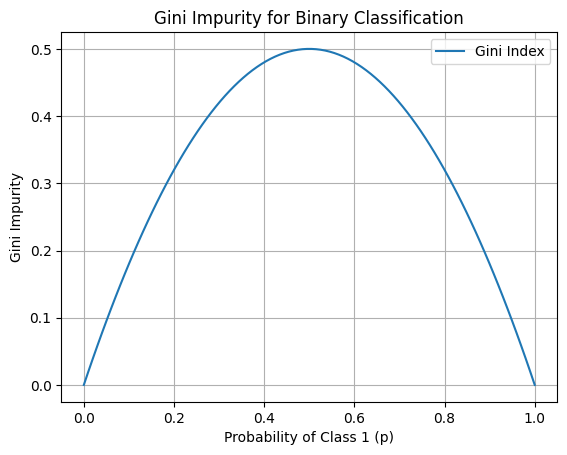

In [1]:
import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(0, 1, 100)
gini = 1 - (p**2 + (1-p)**2)

plt.plot(p, gini, label="Gini Index")
plt.xlabel("Probability of Class 1 (p)")
plt.ylabel("Gini Impurity")
plt.title("Gini Impurity for Binary Classification")
plt.legend()
plt.grid(True)
plt.show()

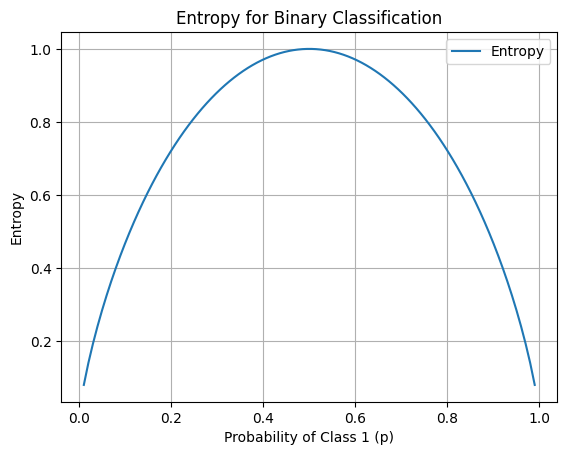

In [3]:
p = np.linspace(0.01, 0.99, 100)
entropy = - (p * np.log2(p) + (1-p) * np.log2(1-p))

plt.plot(p, entropy, label="Entropy")
plt.xlabel("Probability of Class 1 (p)")
plt.ylabel("Entropy")
plt.title("Entropy for Binary Classification")
plt.legend()
plt.grid(True)
plt.show()

## 6. Splitting Criterion and Mathematical Derivation

**Role of Splitting Criterion:**
- Determines which feature and threshold to split on at each node
- Aims to create the most homogeneous child nodes
- Drives the tree construction process

**Mathematical Derivation for Information Gain:**

1. **Calculate parent entropy:**
   ```
   H(S) = -Σ(pi * log2(pi))
   ```

2. **Calculate weighted entropy after split:**
   ```
   H(S|A) = Σ((|Sv|/|S|) * H(Sv))
   ```

3. **Information Gain:**
   ```
   IG(S,A) = H(S) - H(S|A)
   ```

**For Gini Index:**
1. **Parent Gini:**
   ```
   Gini(S) = 1 - Σ(pi)²
   ```

2. **Weighted Gini after split:**
   ```
   Gini(S|A) = Σ((|Sv|/|S|) * Gini(Sv))
   ```

3. **Gini Gain:**
   ```
   Gini_Gain(S,A) = Gini(S) - Gini(S|A)
   ```

# 7. Gini Index vs Entropy Comparison

| Aspect | Gini Index | Entropy |
|--------|------------|---------|
| **Computation** | Faster (no logarithms) | Slower (requires log calculations) |
| **Range** | [0, 0.5] for binary | [0, 1] for binary |
| **Sensitivity** | Less sensitive to probability changes | More sensitive to probability changes |
| **Performance** | Often similar results | Often similar results |
| **Interpretation** | Probability of misclassification | Amount of information needed |

**When to use:**
- **Gini:** When computational efficiency is important
- **Entropy:** When you want maximum information-theoretic splitting
- In practice, both usually produce similar trees

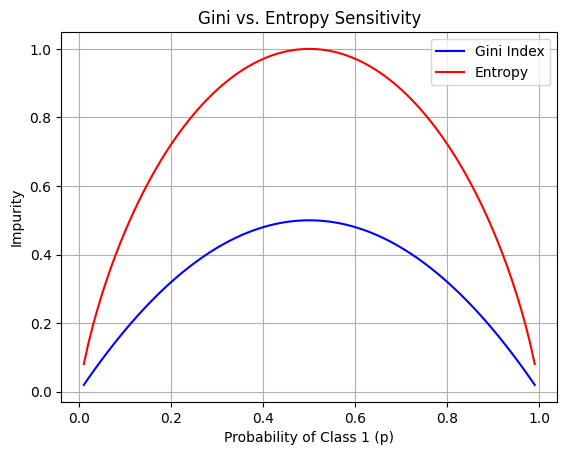

In [5]:
# Visualization (Gini vs. Entropy Sensitivity)
import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(0.01, 0.99, 100)
gini = 1 - (p**2 + (1-p)**2)
entropy = - (p * np.log2(p) + (1-p) * np.log2(1-p))

plt.plot(p, gini, label="Gini Index", color="blue")
plt.plot(p, entropy, label="Entropy", color="red")
plt.xlabel("Probability of Class 1 (p)")
plt.ylabel("Impurity")
plt.title("Gini vs. Entropy Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

## 8. Variance in Regression Trees

**Concept:**
For regression trees, variance measures the spread of target values in a node:
```
Variance = Σ(yi - ȳ)² / n
```
Where yi are individual values and ȳ is the mean.

**Usage:**
- **Splitting criterion:** Choose split that minimizes weighted variance of child nodes
- **Stopping criterion:** Stop splitting when variance falls below threshold
- **Prediction:** Use mean of leaf node values as prediction

**Variance Reduction:**
```
Variance_Reduction = Var(Parent) - Σ((|Sv|/|S|) * Var(Sv))
```

## 9. Post-pruning vs Pre-pruning

**Pre-pruning (Early Stopping):**
- Stops tree growth during construction
- Uses criteria like maximum depth, minimum samples per leaf
- Prevents overfitting before it occurs
- Risk of underfitting (stopping too early)

**Post-pruning:**
- Builds full tree first, then removes branches
- Uses techniques like Reduced Error Pruning or Cost Complexity Pruning
- More computationally expensive
- Generally produces better results

**Key Differences:**
- **Timing:** Pre-pruning during construction vs post-pruning after construction
- **Flexibility:** Post-pruning can reconsider earlier decisions
- **Computational cost:** Pre-pruning is more efficient
- **Performance:** Post-pruning often yields better generalization

## 10. Post-pruning for Reducing Overfitting

**How it works:**
1. Build complete tree using training data
2. Evaluate subtrees on validation data
3. Remove branches that don't improve validation performance
4. Continue until no beneficial pruning possible

**Cost Complexity Pruning (α-pruning):**
```
Cost(T) = Error(T) + α * |T|
```
Where |T| is the number of leaves and α controls pruning strength.

**Benefits:**
- **Reduces overfitting:** Removes branches that memorize training noise
- **Improves generalization:** Better performance on unseen data
- **Maintains interpretability:** Keeps tree structure while reducing complexity
- **Automatic model selection:** Finds optimal tree size


## 11. Pre-pruning Strategy Example

**Example: Minimum Samples Split Strategy**

```python
# Pre-pruning parameters
min_samples_split = 10  # Don't split nodes with fewer than 10 samples
max_depth = 5           # Don't grow trees deeper than 5 levels
min_samples_leaf = 5    # Each leaf must have at least 5 samples
max_features = 'sqrt'   # Consider sqrt(n_features) at each split
```

**Implementation logic:**
```python
def should_split(node):
    if node.n_samples < min_samples_split:
        return False
    if node.depth >= max_depth:
        return False
    if node.n_samples < 2 * min_samples_leaf:
        return False
    return True
```

**Real-world example:**
In customer churn prediction:
- Set `min_samples_split=100` to ensure statistical significance
- Set `max_depth=10` to prevent overly complex rules
- This prevents learning customer-specific patterns that don't generalize


## 12. Implementing Pruning in Python


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

class PrunedDecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, ccp_alpha=0.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.ccp_alpha = ccp_alpha


    def fit(self, X, y):
        # Pre pruning through parameters
        self.tree = DecisionTreeClassifier(max_depth=self.max_depth, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, ccp_alpha=self.ccp_alpha, random_state=4)
        self.tree.fit(X, y)
        return self
    
    def predict(self, X):
        return self.tree.predict(X)
    
    def cost_complexity_pruning(self, X, y, X_val, y_val):
        """Demonstrate cost complexity pruning"""
        # Get cost complexity path
        path = self.tree.cost_complexity_pruning_path(X, y)
        ccp_alphas = path.ccp_alphas
        
        # Train trees for different alpha values
        trees = []
        for alpha in ccp_alphas:
            tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
            tree.fit(X, y)
            trees.append(tree)
        
        # Find best alpha using validation set
        val_scores = [tree.score(X_val, y_val) for tree in trees]
        best_alpha = ccp_alphas[np.argmax(val_scores)]
        
        # Retrain with best alpha
        self.tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
        self.tree.fit(X, y)
        
        return best_alpha


# Usage example
from sklearn.datasets import make_classification

# Generate sample data
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

# Create and train pruned tree
pruned_tree = PrunedDecisionTree()
pruned_tree.fit(X_train, y_train)

# Apply cost complexity pruning
best_alpha = pruned_tree.cost_complexity_pruning(X_train, y_train, X_val, y_val)
print(f"Best alpha: {best_alpha}")
print(f"Test accuracy: {pruned_tree.tree.score(X_test, y_test):.4f}")



Best alpha: 0.005745541459827176
Test accuracy: 0.8800


## 13. Decision Tree Classifier Implementation